# Step 4: Compute a layered layout

-	consider you have a directed graph
-	constract a DAG (directed acyclic graph) by reversing edges - use either the trivial heuristic or the one with guarantees (Eades at al. 93)
-	perform layer assignment (using height minimization)
-	perform iterative crossing minimization using both median and barycenter heuristics
-	assign coordinates to the vertices in any way you like and draw the edges
-	reverse back the edges that have been changed in the first step
-	use Small Directed Network, Pro League Network at this step to experiment with your algorithm.
-	discuss your results and explain your choices of the heuristics carefully. Feel free to use other heuristics for each step but do not forget to explain your choices.


Libraries:

In [3]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path

Graph Datasets

In [10]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/Step1/JazzNetwork.dot" #tree
data_name_2 = "../Dataset/Step1/LesMiserables.dot" #tree
data_name_3 = "../Dataset/OTHERS/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/OTHERS/g.20.27.dot"
data_name_5 = "../Dataset/OTHERS/g.42.88.dot"
data_name_6 = "../Dataset/OTHERS/GD97.dot"
data_name_7 = "../Dataset/OTHERS/LeagueNetwork.dot" #tree
data_name_8 = "../Dataset/OTHERS/mesh graph.dot"
data_name_9 = "../Dataset/OTHERS/smallDirectNetwork.dot"
data_name_10 = "../Dataset/OTHERS/polblogs.dot"
data_name_11 = "../Dataset/OTHERS/robot graph.dot"
data_name_12 = "../Dataset/OTHERS/rome.dot" #tree
data_name_13 = "../Dataset/OTHERS/snail graph.dot"

Main Functions:

# Circular layout

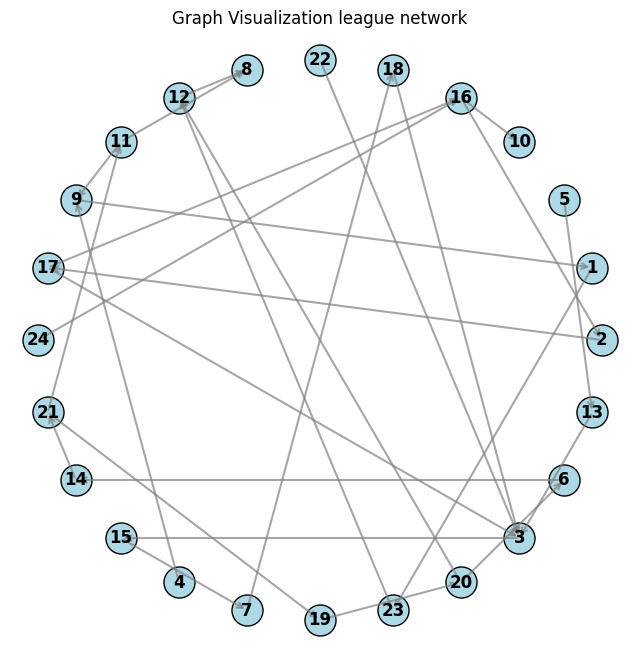

In [11]:
import matplotlib.pyplot as plt
import pydot
import numpy as np

def parse_dot_file(file_path):
    """Parse DOT file and extract nodes and edges."""
    graph = pydot.graph_from_dot_file(file_path)[0]  
    nodes = set()
    edges = []

    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def visualize_graph(nodes, edges):
    """Plot the directed graph using Matplotlib."""
    V = len(nodes)
    
    # Assign positions to nodes (circular layout)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("Graph Visualization league network")
    plt.show()

#use a file
dot_file = data_name_9 
nodes, edges = parse_dot_file(dot_file)
visualize_graph(nodes, edges)


# Random Position

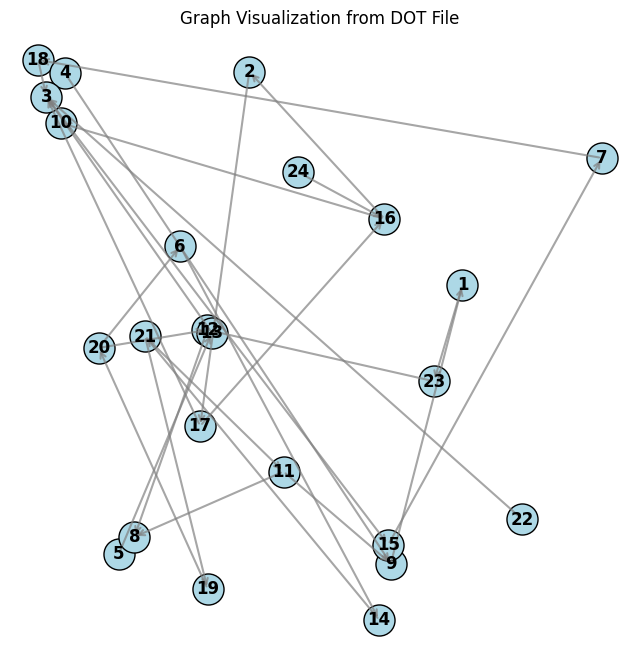

In [13]:
import matplotlib.pyplot as plt
import pydot
import numpy as np

def parse_dot_file(file_path):
    """Parse DOT file and extract nodes and edges."""
    graph = pydot.graph_from_dot_file(file_path)[0] 
    nodes = set()
    edges = []

    # Extract edges and nodes
    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def visualize_graph(nodes, edges):
    """Plot the directed graph using Matplotlib in a more traditional layout."""
    V = len(nodes)
    
    # Assign random positions to nodes for a more spread-out layout
    np.random.seed(42)  # Set seed for reproducibility
    node_positions = {node: (np.random.uniform(-1, 1), np.random.uniform(-1, 1)) for node in nodes}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("Graph Visualization from DOT File")
    plt.show()


dot_file = data_name_9  
nodes, edges = parse_dot_file(dot_file)
visualize_graph(nodes, edges)


# Using DFS

KeyError: '5'

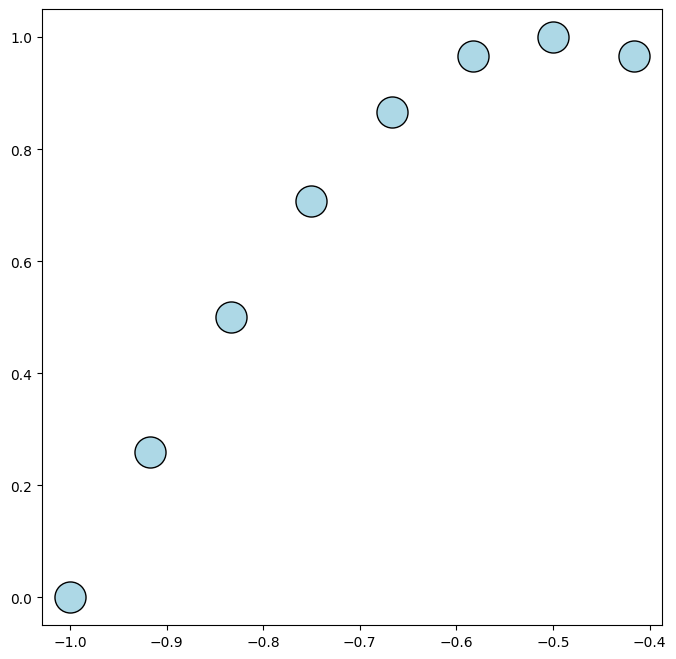

In [18]:
import matplotlib.pyplot as plt
import pydot
import numpy as np

def parse_dot_file(file_path):
    """Parse DOT file and extract nodes and edges."""
    graph = pydot.graph_from_dot_file(file_path)[0]  # Load DOT graph
    nodes = set()
    edges = []

    # Extract edges and nodes
    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def dfs(graph, start, visited, result):
    """DFS traversal of the graph."""
    visited.add(start)
    result.append(start)
    
    # Visit all neighbors
    for neighbor in graph[start]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited, result)

def visualize_graph(nodes, edges):
    """Plot the directed graph using DFS order."""
    # Create an adjacency list for DFS traversal
    adj_list = {node: [] for node in nodes}
    for src, dst in edges:
        adj_list[src].append(dst)

    # Perform DFS starting from an arbitrary node (first node in the list)
    visited = set()
    dfs_result = []
    dfs(adj_list, nodes[0], visited, dfs_result)

    # Assign positions based on DFS result (sequential order)
    V = len(nodes)
    node_positions = {node: (i / V * 2 - 1, np.sin(i / V * 2 * np.pi)) for i, node in enumerate(dfs_result)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')
    
    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("DFS Traversal Graph Visualization")
    plt.show()


dot_file = data_name_9  
nodes, edges = parse_dot_file(dot_file)
visualize_graph(nodes, edges)


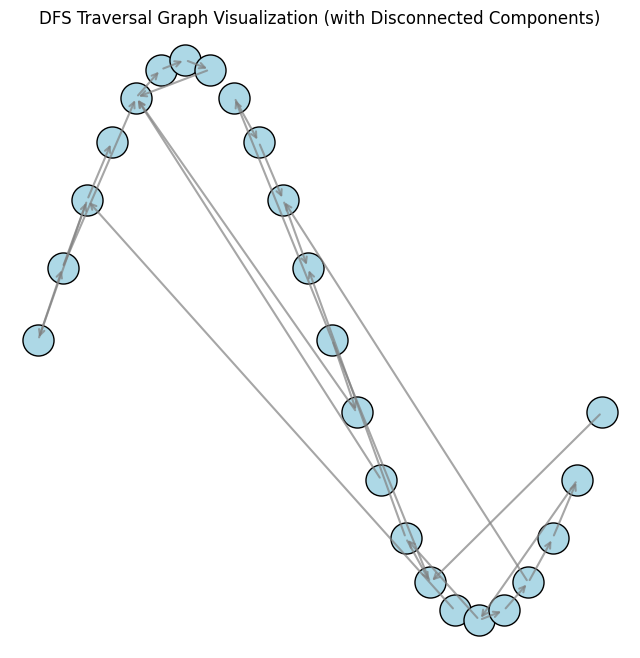

In [21]:
def visualize_graph(nodes, edges):
    """Plot the directed graph using DFS order."""
    # Create an adjacency list for DFS traversal
    adj_list = {node: [] for node in nodes}
    for src, dst in edges:
        adj_list[src].append(dst)

    # Handle disconnected components by running DFS from each unvisited node
    visited = set()
    dfs_result = []
    
    # Run DFS from each unvisited node
    for node in nodes:
        if node not in visited:
            dfs(adj_list, node, visited, dfs_result)

    # Assign positions based on DFS result (sequential order)
    V = len(nodes)
    node_positions = {node: (i / V * 2 - 1, np.sin(i / V * 2 * np.pi)) 
                     for i, node in enumerate(dfs_result)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", 
              edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    """
    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')
    """
    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("DFS Traversal Graph Visualization (with Disconnected Components)")
    plt.show()


dot_file = data_name_9  
nodes, edges = parse_dot_file(dot_file)
visualize_graph(nodes, edges)